# AIoT Project
## Featuring Engineering


This notebook is the entry point for the Feature Engineering analysis pipeline.

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path, encoding="utf-8") as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
client = pymongo.MongoClient(config["client"])

In [5]:
db = client[config["db"]]
coll = db[config["col"]]
found_labels = coll.distinct("activity_label")
print("Activities in DB:", found_labels)

Activities in DB: ['Nordic walking', 'ascending stairs', 'cycling', 'descending stairs', 'ironing', 'lying', 'rope jumping', 'running', 'sitting', 'standing', 'vacuum cleaning', 'walking']


## Load data

The documents that correspond to the **IMU HAND AccGyr sensor configuration**. 



In [6]:
query = {"split":"Protocol", "imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))

In [7]:

df_segments = pd.DataFrame(documents)
print(df_segments.columns)


Index(['_id', 'data', 'activity_id', 'activity_label', 'subject', 'split',
       'imu_location', 'sensor', 'sr', 'datetime'],
      dtype='str')


## Explore the nature of the data

Suggested exploratory plots for the PAMAP2 instances you loaded:

* Total recording time per activity (sum of segment lengths in seconds, grouped by `activity_label`).
* A time-domain plot of one segment per activity, so you can see the signal shape of each class.
* The distribution of segment counts per `(subject, activity_label)` pair — this exposes the class imbalance you will need to address.

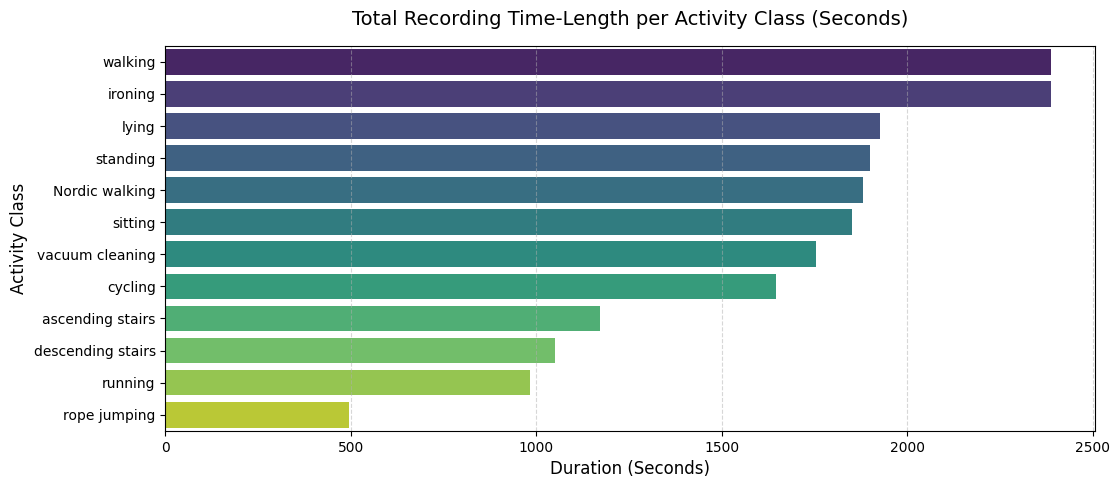

In [8]:
df_segments['num_samples'] = df_segments['data'].apply(lambda x: len(x['acc_x']))
df_segments['duration_seconds'] = df_segments['num_samples'] / 100.0

activity_time = df_segments.groupby('activity_label')['duration_seconds'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=activity_time.values, y=activity_time.index, hue=activity_time.index, palette='viridis', legend=False)
plt.title('Total Recording Time-Length per Activity Class (Seconds)', fontsize=14, pad=15)
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Activity Class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


['Nordic walking', 'ascending stairs', 'cycling', 'descending stairs', 'ironing', 'lying', 'rope jumping', 'running', 'sitting', 'standing', 'vacuum cleaning', 'walking']


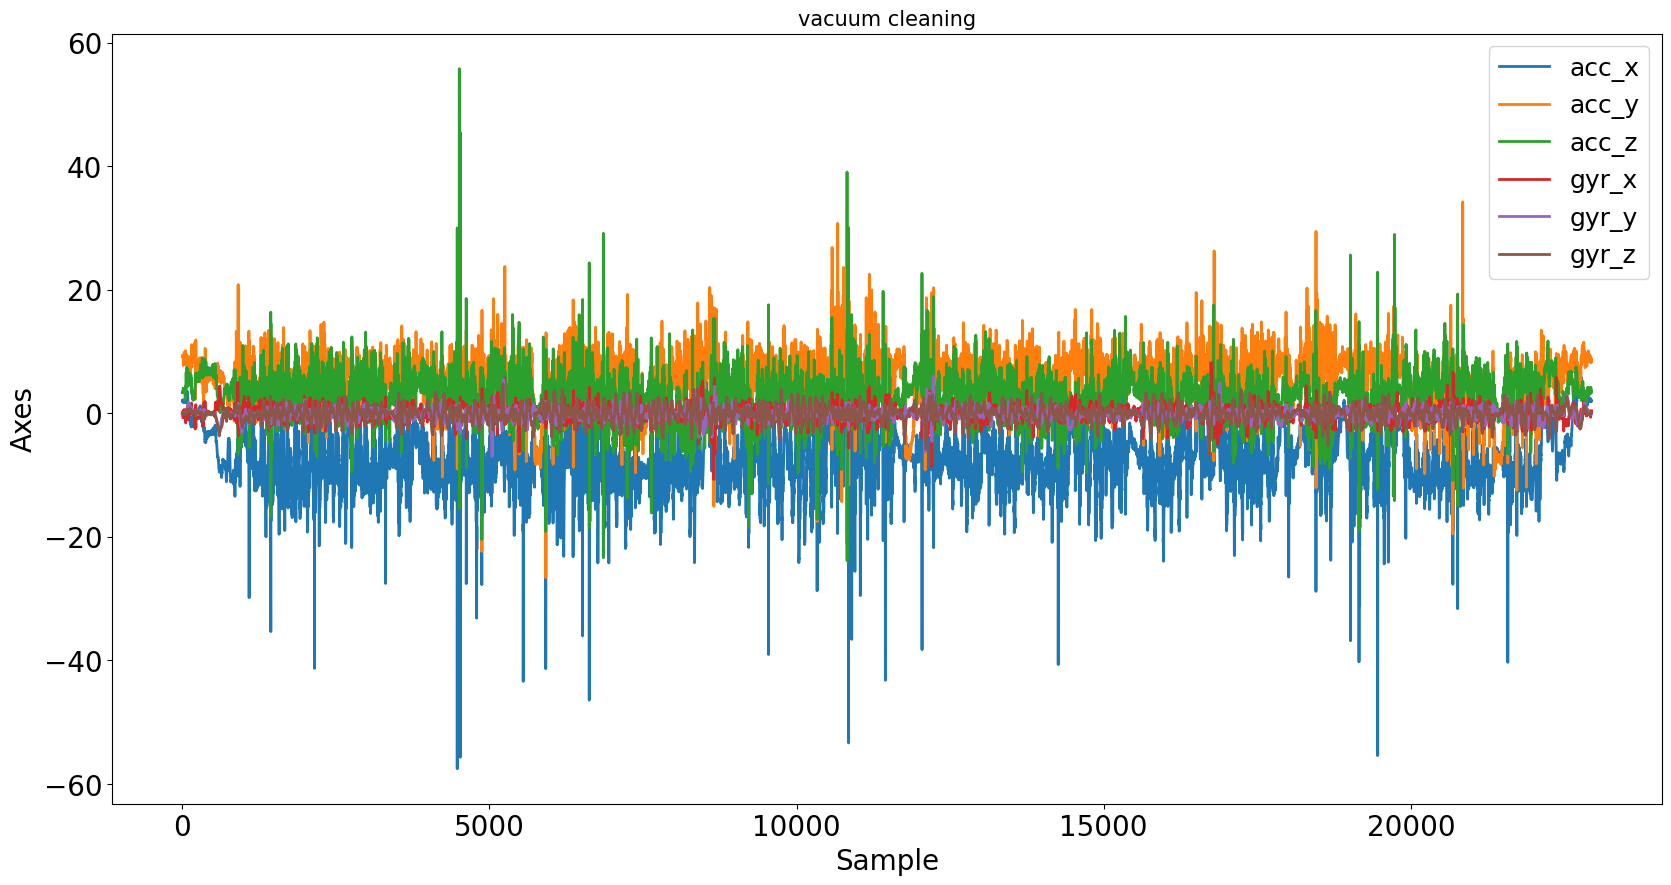

In [9]:
print (found_labels)
sample = df_segments[df_segments['activity_label'] == 'vacuum cleaning'].iloc[0]

sample_signal_df = pd.DataFrame(dict(sample['data']))

plot_instance_time_domain(sample_signal_df)
plt.title(f"{sample['activity_label']}", fontsize=15)
plt.show()

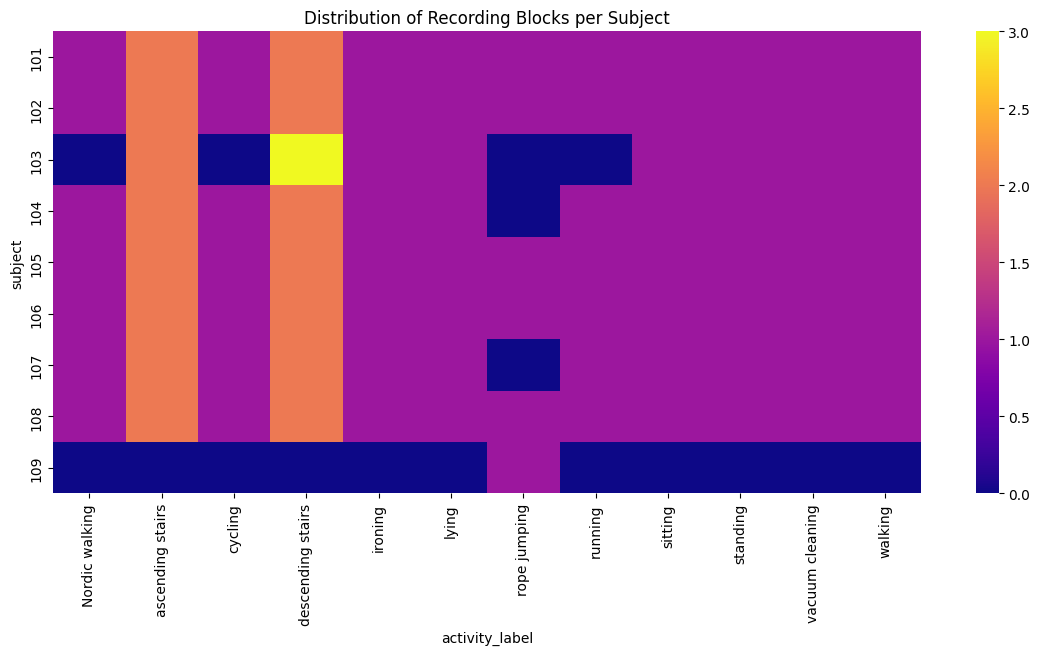

In [10]:
imbalance_matrix = pd.crosstab(df_segments['subject'], df_segments['activity_label'])

plot_heatmap(imbalance_matrix)
plt.title("Distribution of Recording Blocks per Subject")
plt.show()

## Data Processing
Train & Test Split And Windowing

In [11]:
TRAIN_SUBJECTS = ["101", "102", "103", "104", "105", "107"]
TEST_SUBJECTS  = ["106", "108", "109"]

assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

train_segments = df_segments[df_segments["subject"].astype(str).isin(TRAIN_SUBJECTS)]
test_segments  = df_segments[df_segments["subject"].astype(str).isin(TEST_SUBJECTS)]

from utils import make_pairs


training_windowpairs = make_pairs(train_segments,config) #Custom function to create window pairs from segments training segments
test_windowpairs     = make_pairs(test_segments,config) #Custom function to create window pairs from segments test segments



print(f"Train segments: {len(train_segments)}")
print(f"Test segments:  {len(test_segments)}")

print(f"Total window instances generated across training_subject segments: {len(training_windowpairs)}")
print(f"Total window instances generated across test_subject segments: {len(test_windowpairs)}")
print(f"Total window instances generated across both training and test segments: {len(training_windowpairs) + len(test_windowpairs)}")

Train segments: 79
Test segments:  29
Total window instances generated across training_subject segments: 4000
Total window instances generated across test_subject segments: 1379
Total window instances generated across both training and test segments: 5379


In [12]:
from utils import filter_pairs

filtered_training_list = filter_pairs(training_windowpairs, config)#Custom function to filter window pairs 
filtered_test_list     = filter_pairs(test_windowpairs, config)#Custom function to filter window pairs

print(f"Filtered train windows : {len(filtered_training_list)}")
print(f"Filtered test windows  : {len(filtered_test_list)}")


Filtered train windows : 4000
Filtered test windows  : 1379


# Inspection of Windowed Signals Before Filtering and After Filterring

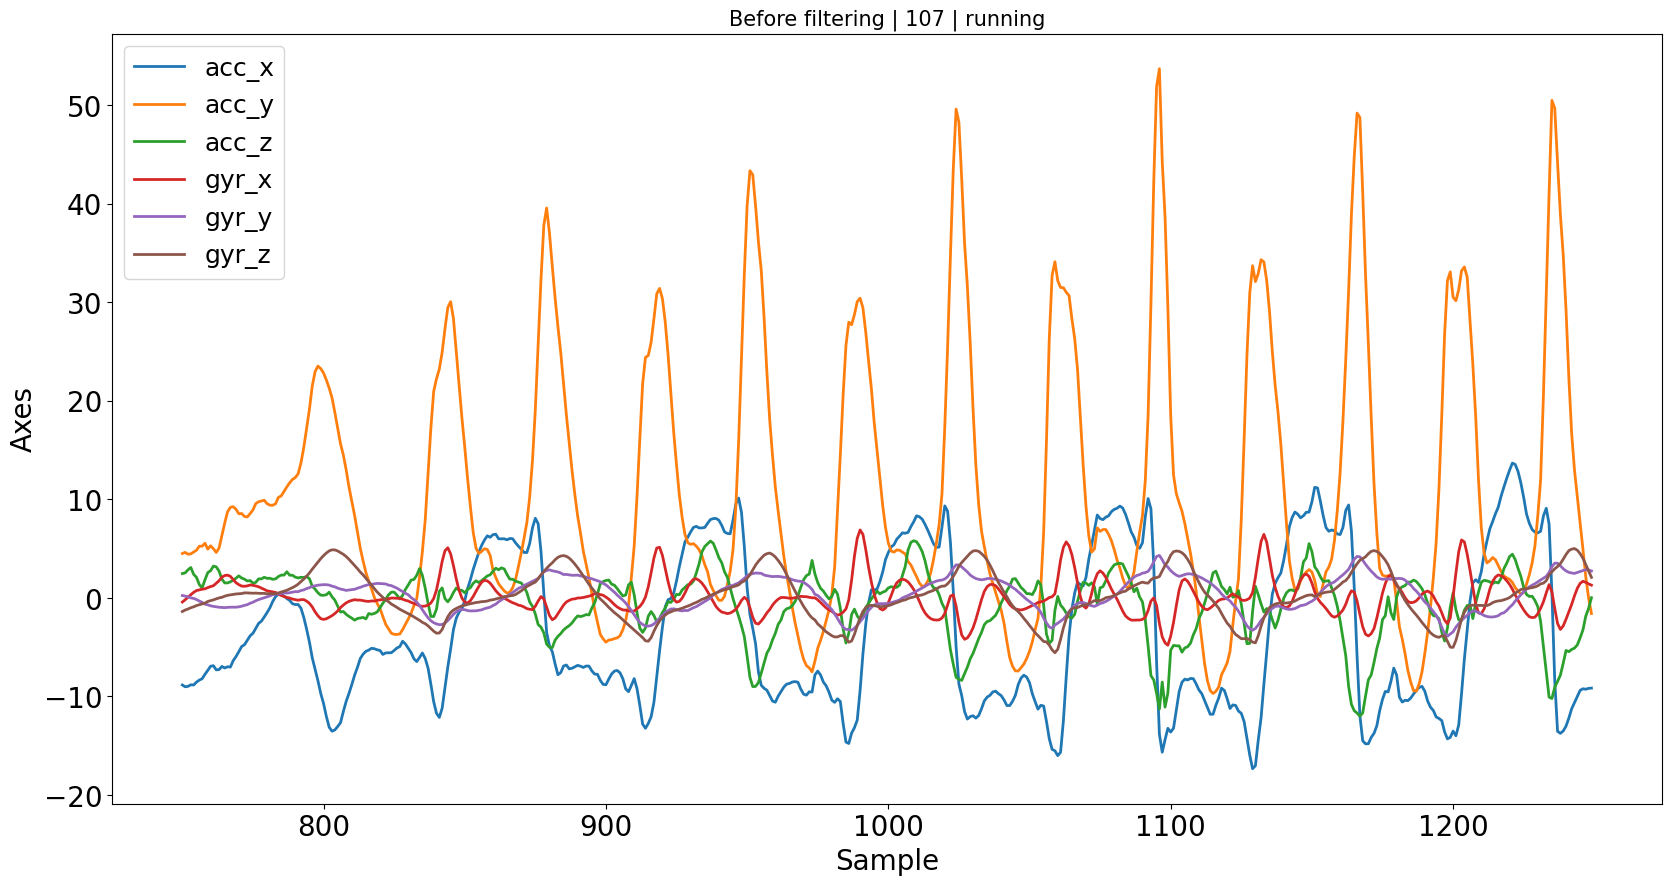

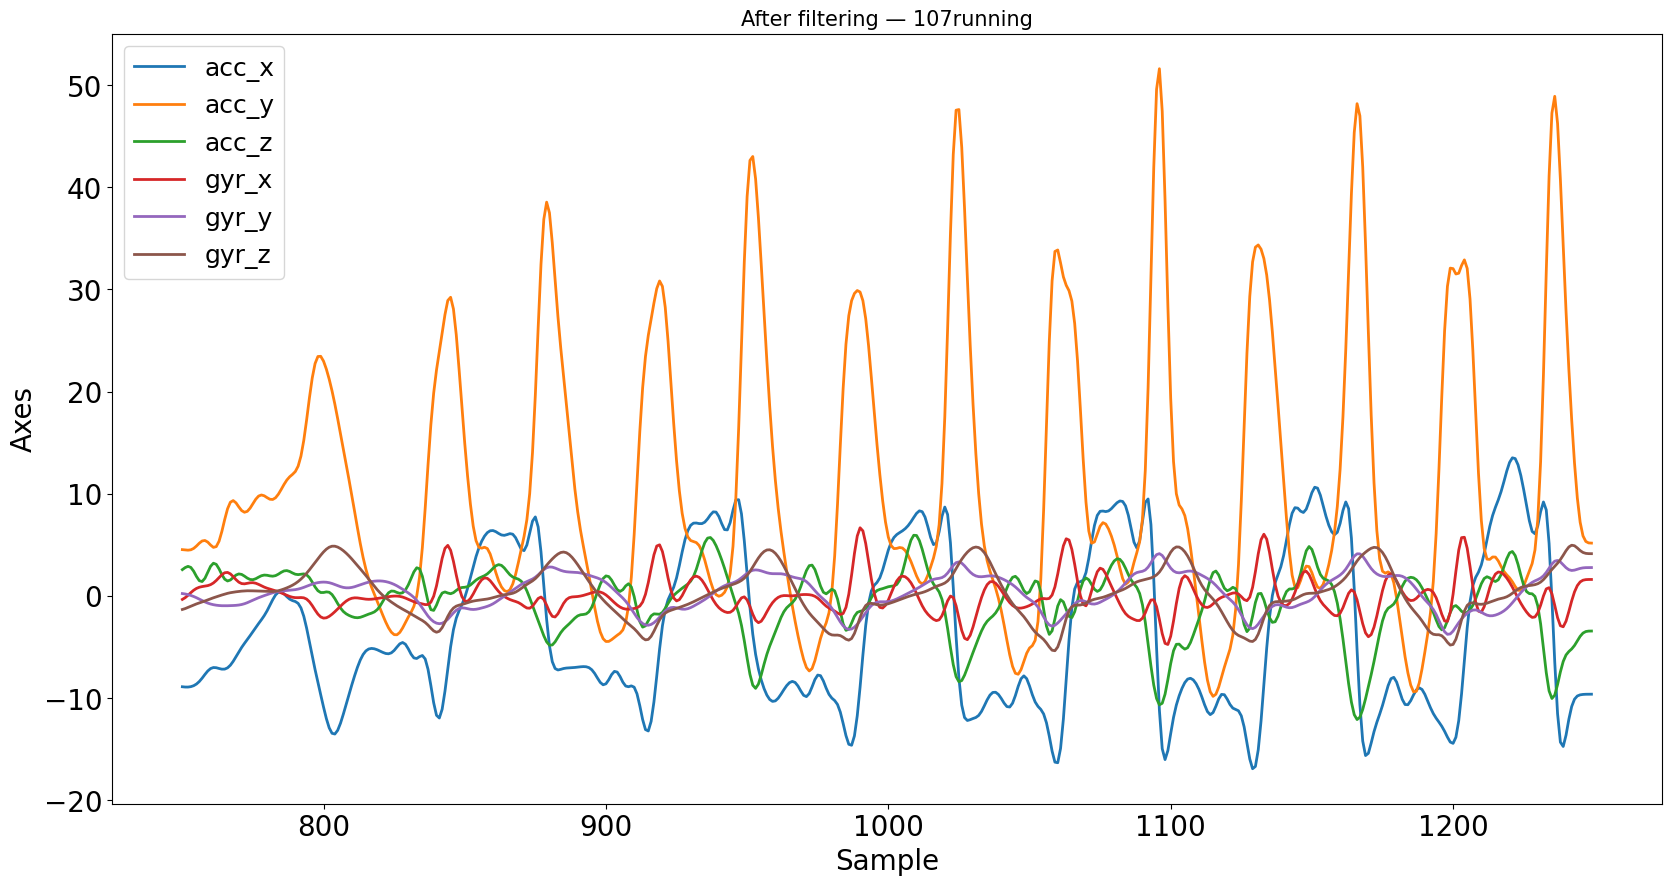

In [13]:
i = 3999 # change to inspect different windows
# Before

plot_instance_time_domain(training_windowpairs[i]['window'])
plt.title(f"Before filtering | {training_windowpairs[i]['subject']} | {training_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()

# After

plot_instance_time_domain(filtered_training_list[i])
plt.title(f"After filtering — {training_windowpairs[i]['subject']}{training_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()



# Same for Test Subjects

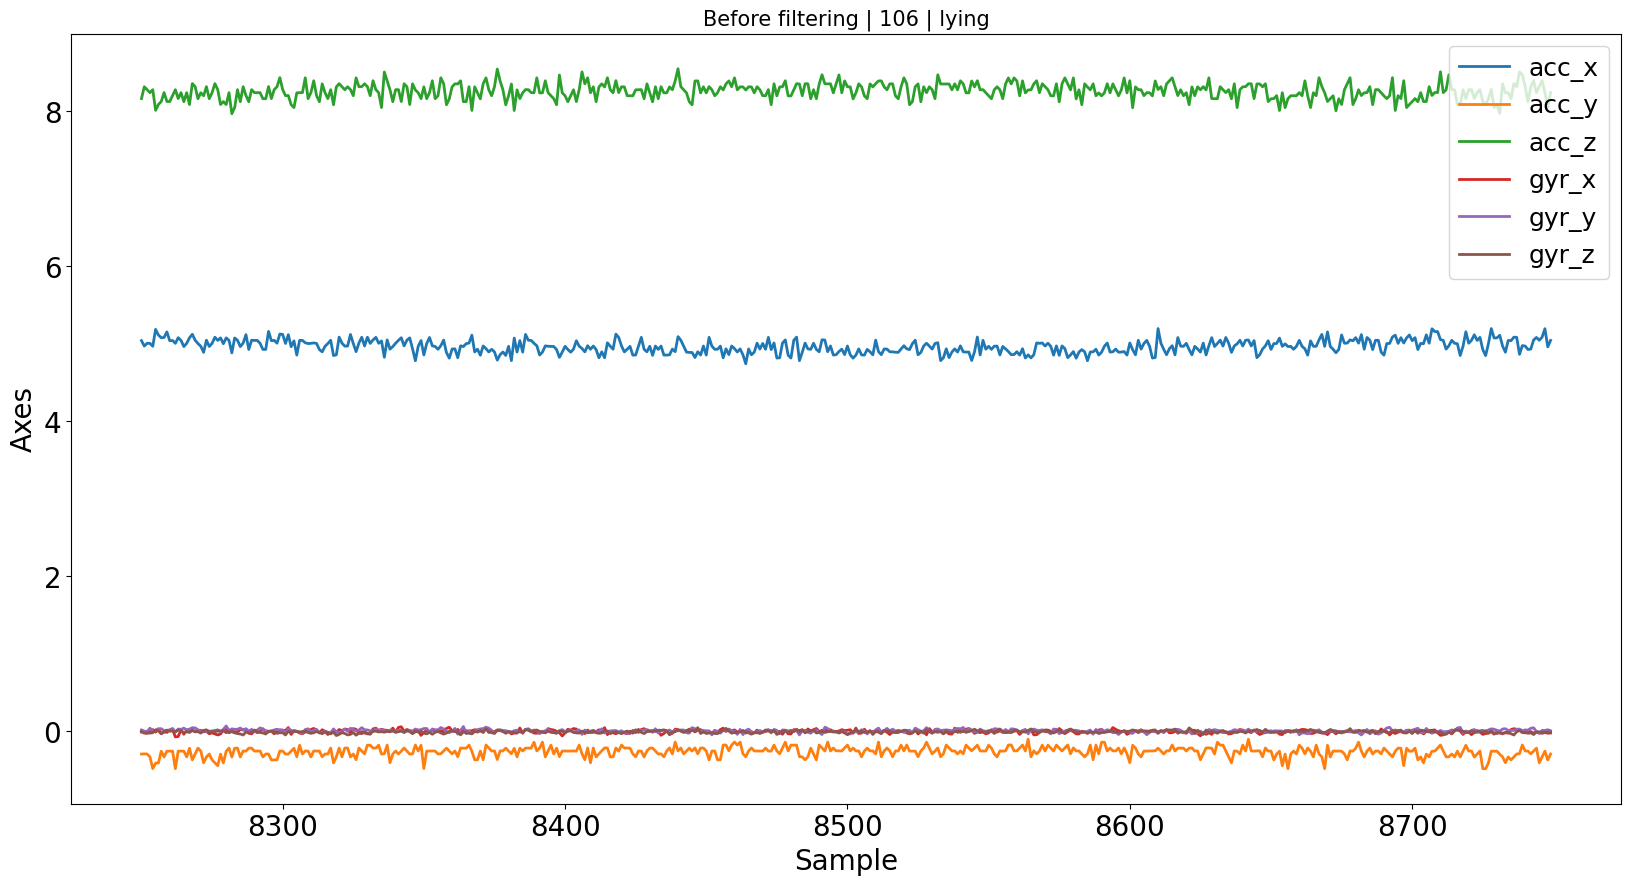

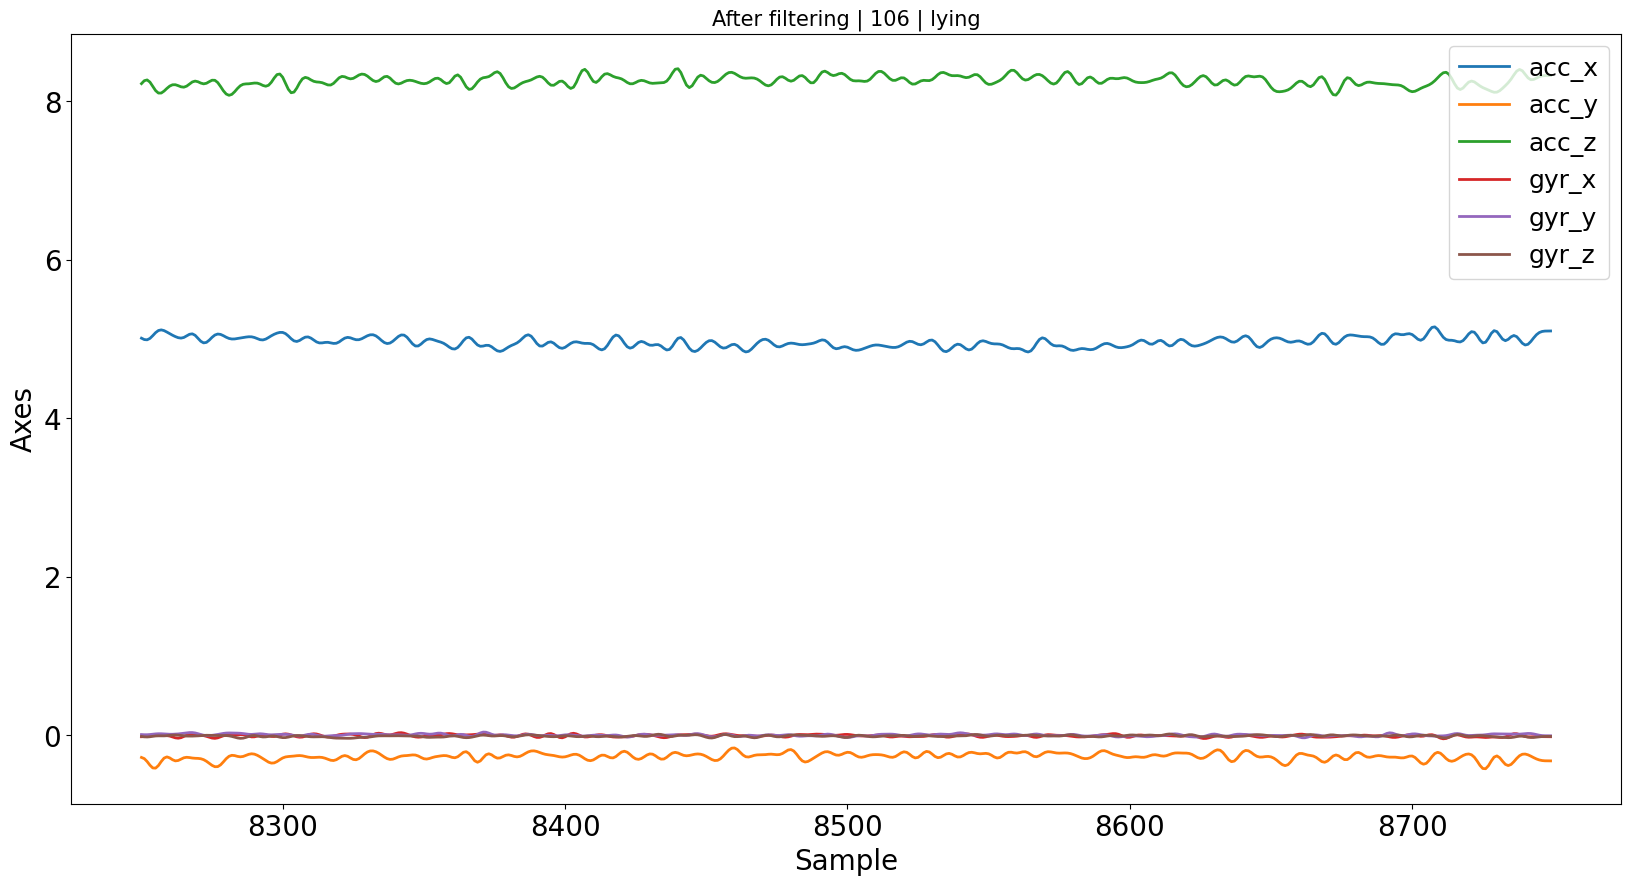

In [14]:
i = 30 # change to inspect different windows
# Before

plot_instance_time_domain(test_windowpairs[i]['window'])
plt.title(f"Before filtering | {test_windowpairs[i]['subject']} | {test_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()

# After

plot_instance_time_domain(filtered_test_list[i])
plt.title(f"After filtering | {test_windowpairs[i]['subject']} | {test_windowpairs[i]['activity_label']}", fontsize=15)
plt.show()


# NaN Values Check

In [15]:
# ── NaN check after filtering ────────────────────────────────────────────────
nan_train = sum(df.isnull().values.any() for df in filtered_training_list)
nan_test  = sum(df.isnull().values.any() for df in filtered_test_list)

print(f"Train windows with NaN: {nan_train} / {len(filtered_training_list)}")
print(f"Test windows with NaN:  {nan_test}  / {len(filtered_test_list)}")

assert nan_train == 0, "NaN values found in training set!"
assert nan_test  == 0, "NaN values found in test set!"

print(" No NaN values found —")

Train windows with NaN: 0 / 4000
Test windows with NaN:  0  / 1379
 No NaN values found —


# Feature Extraction
We extract 9 statistical time-domain features per axis from each filtered window:
`mean`, `std`, `min`, `max`, `median`, `energy`, `IQR`, `skewness`, `kurtosis`
and 4 frequency-doamin features:    
    `dominant frequency` , `spectral energy` , ` spectral entropy` , `mean frequency`

For 6-axis IMU data this produces **78 features per window** — a compact, meaningful representation compared to the 3000-element raw flattened vector used in the time-series notebook.

In [16]:
from utils import build_feature_matrix, encode_labels

X_train_fe = build_feature_matrix(filtered_training_list)
X_test_fe  = build_feature_matrix(filtered_test_list)

feature_names = X_train_fe.columns.tolist()

y_train = encode_labels([p["activity_label"] for p in training_windowpairs])
y_test  = encode_labels([p["activity_label"] for p in test_windowpairs])

print(f"X_train_fe: {X_train_fe.shape}")  # (n_windows, n_features)
print(f"X_test_fe:  {X_test_fe.shape}")
print(f"Features:   {feature_names}")

X_train_fe: (4000, 78)
X_test_fe:  (1379, 78)
Features:   ['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_median', 'acc_x_energy', 'acc_x_iqr', 'acc_x_skew', 'acc_x_kurtosis', 'acc_x_dom_freq', 'acc_x_spec_energy', 'acc_x_spec_entropy', 'acc_x_mean_freq', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_median', 'acc_y_energy', 'acc_y_iqr', 'acc_y_skew', 'acc_y_kurtosis', 'acc_y_dom_freq', 'acc_y_spec_energy', 'acc_y_spec_entropy', 'acc_y_mean_freq', 'acc_z_mean', 'acc_z_std', 'acc_z_min', 'acc_z_max', 'acc_z_median', 'acc_z_energy', 'acc_z_iqr', 'acc_z_skew', 'acc_z_kurtosis', 'acc_z_dom_freq', 'acc_z_spec_energy', 'acc_z_spec_entropy', 'acc_z_mean_freq', 'gyr_x_mean', 'gyr_x_std', 'gyr_x_min', 'gyr_x_max', 'gyr_x_median', 'gyr_x_energy', 'gyr_x_iqr', 'gyr_x_skew', 'gyr_x_kurtosis', 'gyr_x_dom_freq', 'gyr_x_spec_energy', 'gyr_x_spec_entropy', 'gyr_x_mean_freq', 'gyr_y_mean', 'gyr_y_std', 'gyr_y_min', 'gyr_y_max', 'gyr_y_median', 'gyr_y_energy', 'gyr_y_iqr', 'gy

# Scaling
We fit `StandardScaler` on training data only, then transform both train and test sets. Fitting on test data would constitute **Scaler Leakage** — the test statistics would influence normalisation and inflate reported metrics.

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_fe)
X_test  = scaler.transform(X_test_fe)

# Feature Selection

## Correlation Filter (Spearman)
We remove redundant features before ranking. If two features have |r| > 0.9 they carry almost identical information — keeping both wastes a feature slot without adding discriminative power.

**Spearman** is used instead of Pearson because IMU features such as `energy` and `kurtosis` exhibit heavy-tailed distributions and monotonic rather than strictly linear relationships.

In [18]:
feature_df  = pd.DataFrame(X_train, columns=feature_names)
corr_matrix = feature_df.corr(method="spearman")

# find highly correlated pairs
threshold  = 0.9
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > threshold:
            corr_pairs.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "r":         round(r, 3)
            })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values("r", ascending=False)
print(f"Highly correlated pairs (|r| > {threshold}): {len(corr_pairs_df)}")
print(corr_pairs_df.to_string(index=False))

# drop one from each correlated pair
to_drop = set()
for _, row in corr_pairs_df.iterrows():
    if row["Feature 2"] not in to_drop:
        to_drop.add(row["Feature 2"])

keep_features = [f for f in feature_names if f not in to_drop]
keep_indices  = [feature_names.index(f) for f in keep_features]

X_train_corr = X_train[:, keep_indices]
X_test_corr  = X_test[:,  keep_indices]

print(f"\nDropped  : {len(to_drop)} features")
print(f"Remaining: {len(keep_features)} features")

Highly correlated pairs (|r| > 0.9): 61
         Feature 1          Feature 2      r
         gyr_x_std       gyr_x_energy  0.999
      gyr_y_energy  gyr_y_spec_energy  0.999
      gyr_z_energy  gyr_z_spec_energy  0.999
      gyr_x_energy  gyr_x_spec_energy  0.999
         gyr_y_std       gyr_y_energy  0.998
         gyr_z_std       gyr_z_energy  0.998
         gyr_x_std  gyr_x_spec_energy  0.997
         gyr_z_std  gyr_z_spec_energy  0.996
         gyr_y_std  gyr_y_spec_energy  0.995
      acc_x_energy  acc_x_spec_energy  0.991
      acc_z_energy  acc_z_spec_energy  0.991
      acc_y_energy  acc_y_spec_energy  0.990
        acc_z_mean       acc_z_median  0.986
        acc_x_mean       acc_x_median  0.984
        acc_y_mean       acc_y_median  0.977
acc_y_spec_entropy    acc_y_mean_freq  0.974
acc_z_spec_entropy    acc_z_mean_freq  0.973
         acc_x_std          acc_x_iqr  0.967
         gyr_z_std          gyr_z_max  0.965
         acc_y_std          acc_y_iqr  0.963
         gyr_z_

In [19]:
# list of features that survived the filter
print(f"Remaining features ({len(keep_features)}):")
for i, f in enumerate(keep_features):
    print(f"  {i+1:2d}. {f}")

Remaining features (48):
   1. acc_x_mean
   2. acc_x_std
   3. acc_x_min
   4. acc_x_max
   5. acc_x_energy
   6. acc_x_skew
   7. acc_x_kurtosis
   8. acc_x_dom_freq
   9. acc_x_spec_entropy
  10. acc_y_mean
  11. acc_y_std
  12. acc_y_min
  13. acc_y_max
  14. acc_y_skew
  15. acc_y_kurtosis
  16. acc_y_dom_freq
  17. acc_y_spec_entropy
  18. acc_z_mean
  19. acc_z_std
  20. acc_z_min
  21. acc_z_max
  22. acc_z_energy
  23. acc_z_skew
  24. acc_z_kurtosis
  25. acc_z_dom_freq
  26. gyr_x_mean
  27. gyr_x_std
  28. gyr_x_median
  29. gyr_x_skew
  30. gyr_x_kurtosis
  31. gyr_x_dom_freq
  32. gyr_x_spec_entropy
  33. gyr_y_mean
  34. gyr_y_std
  35. gyr_y_median
  36. gyr_y_skew
  37. gyr_y_kurtosis
  38. gyr_y_dom_freq
  39. gyr_y_spec_entropy
  40. gyr_y_mean_freq
  41. gyr_z_mean
  42. gyr_z_std
  43. gyr_z_median
  44. gyr_z_skew
  45. gyr_z_kurtosis
  46. gyr_z_dom_freq
  47. gyr_z_spec_entropy
  48. gyr_z_mean_freq


## ANOVA F-score 
We Rank remaining features by how well they separate activity classes. A high F-score means the feature varies significantly **between** classes relative to variation **within** classes.

ANOVA is fast and interpretable but assumes linear separability — validated against RF importance in the next step.

Top 10 most discriminative (ANOVA):
     Feature     F_score  p_value
   acc_y_max 1056.600984      0.0
   acc_y_std 1039.854320      0.0
   acc_x_min  884.810144      0.0
  acc_x_mean  732.074591      0.0
   acc_x_std  663.519697      0.0
   gyr_z_std  659.733142      0.0
   gyr_y_std  468.719967      0.0
   gyr_x_std  468.101456      0.0
acc_z_energy  344.420171      0.0
   acc_z_std  288.558681      0.0

Bottom 5 least discriminative (ANOVA):
       Feature  F_score      p_value
acc_x_dom_freq 7.385141 1.175444e-12
    gyr_x_skew 5.876828 1.523979e-09
    gyr_z_skew 5.868386 1.585444e-09
acc_y_dom_freq 5.063292 6.621440e-08
    gyr_y_skew 2.236568 1.058821e-02


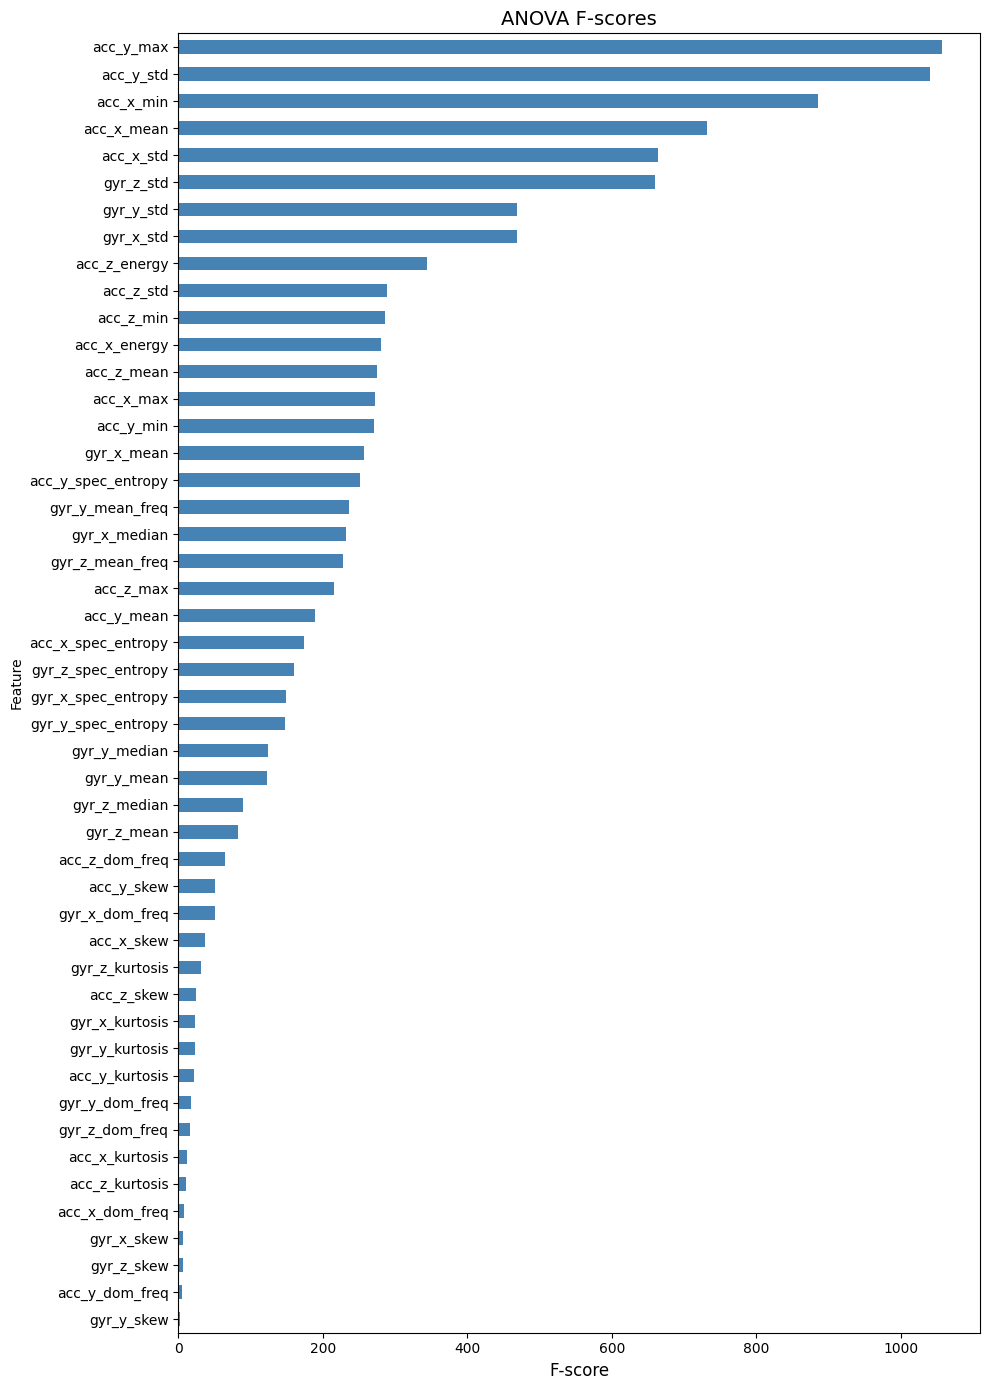

In [20]:

from sklearn.feature_selection import f_classif

f_scores, p_values = f_classif(X_train_corr, y_train)

anova_df = pd.DataFrame({
    "Feature": keep_features,
    "F_score": f_scores,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

print("Top 10 most discriminative (ANOVA):")
print(anova_df.head(10).to_string(index=False))
print("\nBottom 5 least discriminative (ANOVA):")
print(anova_df.tail(5).to_string(index=False))

# plot
plt.figure(figsize=(10, 14))
anova_df.set_index("Feature")["F_score"].sort_values().plot(
    kind="barh", color="steelblue")
plt.title("ANOVA F-scores", fontsize=14)
plt.xlabel("F-score", fontsize=12)
plt.tight_layout()
plt.show()

# select top N
TOP_N        = 30
top_anova    = anova_df.head(TOP_N)["Feature"].tolist()

## Random Forest Importance
We validate the ANOVA ranking using Random Forest feature importances. RF captures non-linear relationships that ANOVA misses. If rankings agree (≥70% overlap in top-N) → trust ANOVA. If they disagree significantly → use Mutual Information.

RF Feature Importances:
           Feature  Importance
         acc_x_min    0.087371
        acc_x_mean    0.058899
      acc_x_energy    0.048561
         acc_x_max    0.046661
         acc_x_std    0.042361
         gyr_z_std    0.040727
         acc_y_max    0.039480
      acc_z_energy    0.037128
         acc_y_std    0.034683
        acc_z_mean    0.034549
        acc_y_mean    0.034465
         gyr_y_std    0.032428
acc_x_spec_entropy    0.031871
         acc_z_min    0.027200
      gyr_x_median    0.026026
        gyr_x_mean    0.024991
         gyr_x_std    0.024770
         acc_z_std    0.023695
acc_y_spec_entropy    0.022649
         acc_y_min    0.021496
   gyr_y_mean_freq    0.020517
         acc_z_max    0.018222
gyr_y_spec_entropy    0.014548
   gyr_z_mean_freq    0.013243
        gyr_y_mean    0.013082
        gyr_z_mean    0.013042
        acc_x_skew    0.012793
        acc_y_skew    0.011869
    acc_x_kurtosis    0.011537
      gyr_y_median    0.011435
    gyr_z_kurto

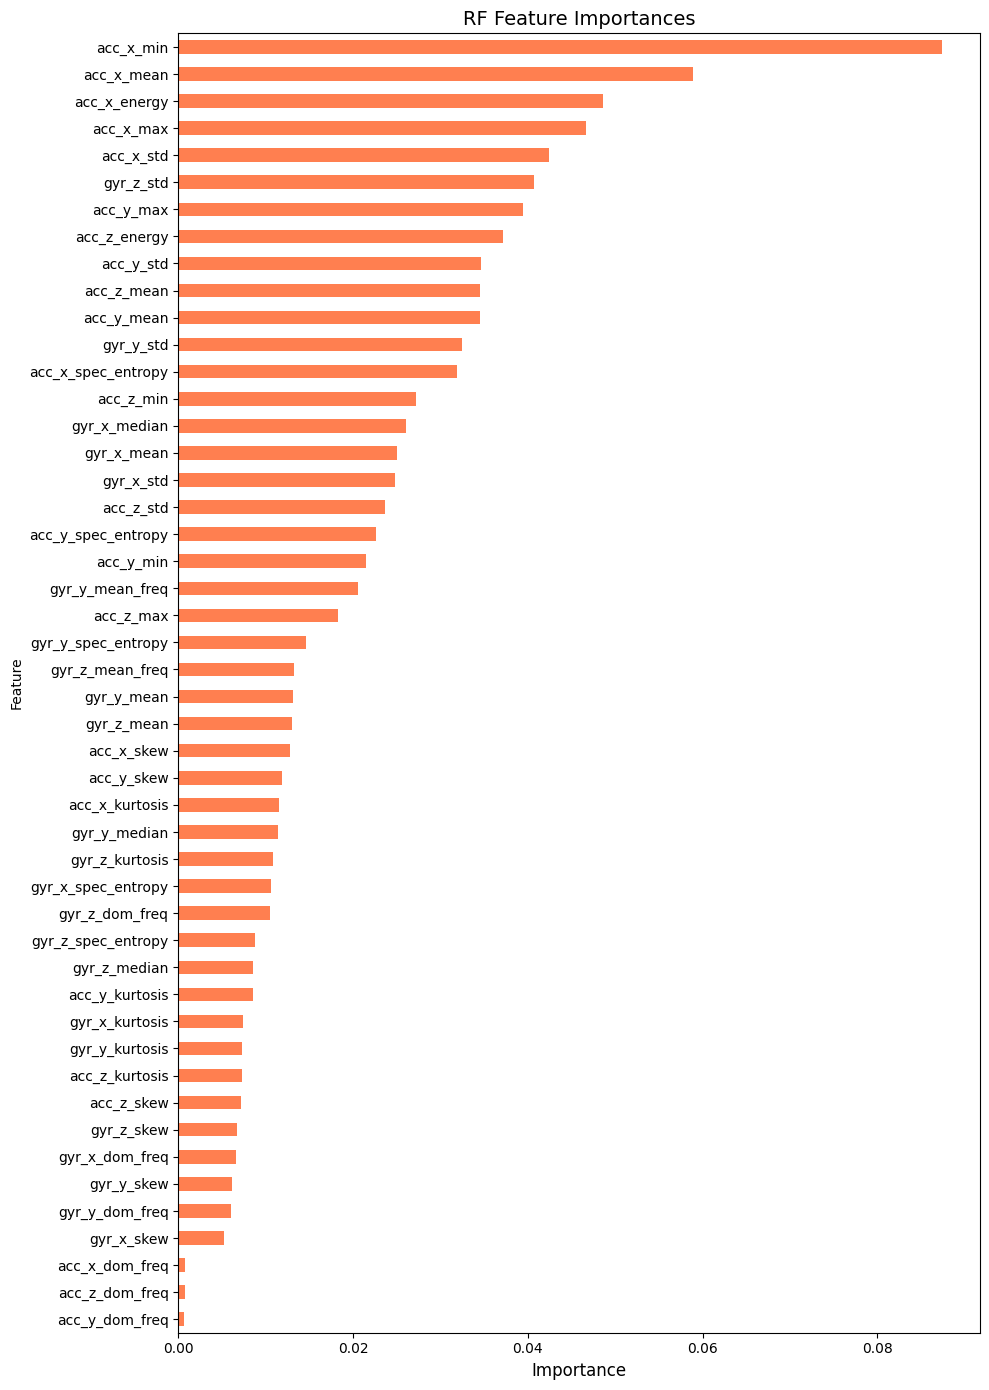

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_corr, y_train)

rf_importance_df = pd.DataFrame({
    "Feature":    keep_features,
    "Importance": rf_selector.feature_importances_
}).sort_values("Importance", ascending=False)

print("RF Feature Importances:")
print(rf_importance_df.to_string(index=False))

# plot
plt.figure(figsize=(10, 14))
rf_importance_df.set_index("Feature")["Importance"].sort_values().plot(
    kind="barh", color="coral")
plt.title("RF Feature Importances", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.tight_layout()
plt.show()

## ANOVA F Vs RF Importance

We Cross-examine all three ranking methods. Features where all three agree are the most reliable selections. Features with high disagreement between ANOVA and RF suggest non-linear class relationships.

In [22]:
comparison_df = anova_df[["Feature", "F_score"]].merge(
    rf_importance_df[["Feature", "Importance"]],
    on="Feature"
).sort_values("F_score", ascending=False).reset_index(drop=True)

# add rank columns
comparison_df["ANOVA_rank"] = range(1, len(comparison_df)+1)
comparison_df["RF_rank"]    = comparison_df["Importance"].rank(
                                ascending=False).astype(int)
comparison_df["rank_diff"]  = abs(comparison_df["ANOVA_rank"] - comparison_df["RF_rank"])

print("ANOVA vs RF Feature Ranking Comparison:")
print(comparison_df.to_string(index=False))

# agreement check
TOP_N   = 48
top_anova = set(anova_df.head(TOP_N)["Feature"].tolist())
top_rf    = set(rf_importance_df.head(TOP_N)["Feature"].tolist())
overlap   = top_anova & top_rf

print(f"\nTop {TOP_N} overlap: {len(overlap)}/{TOP_N} features agree")

if len(overlap) >= TOP_N * 0.7:
    print(" Rankings agree — use ANOVA selection")
else:
    print(" Rankings disagree — consider Mutual Information")

ANOVA vs RF Feature Ranking Comparison:
           Feature     F_score  Importance  ANOVA_rank  RF_rank  rank_diff
         acc_y_max 1056.600984    0.039480           1        7          6
         acc_y_std 1039.854320    0.034683           2        9          7
         acc_x_min  884.810144    0.087371           3        1          2
        acc_x_mean  732.074591    0.058899           4        2          2
         acc_x_std  663.519697    0.042361           5        5          0
         gyr_z_std  659.733142    0.040727           6        6          0
         gyr_y_std  468.719967    0.032428           7       12          5
         gyr_x_std  468.101456    0.024770           8       17          9
      acc_z_energy  344.420171    0.037128           9        8          1
         acc_z_std  288.558681    0.023695          10       18          8
         acc_z_min  285.900653    0.027200          11       14          3
      acc_x_energy  280.113732    0.048561          12      

## Final Feature Handpick
We select features where at least two of three methods (ANOVA, RF, MI) agree they are discriminative. WE drop features that all three methods consistently rank at the bottom.

**Feature reduction:** 78 → 48 (Spearman filter) → 17 (handpicked) →  (PCA components)

In [23]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train_corr, y_train, random_state=42)
mi_df = pd.DataFrame({
    "Feature":  keep_features,
    "MI_score": mi_scores
}).sort_values("MI_score", ascending=False)

print("Top 48 (Mutual Information):")
print(mi_df.head(48).to_string(index=False))

Top 48 (Mutual Information):
           Feature  MI_score
         acc_x_min  1.116393
        acc_x_mean  0.855303
      acc_x_energy  0.851067
         gyr_z_std  0.778388
         acc_y_max  0.759498
         acc_z_min  0.757735
         acc_x_max  0.738654
         acc_x_std  0.707321
         acc_y_min  0.696144
         acc_y_std  0.695511
         gyr_y_std  0.675988
         acc_z_max  0.666508
         gyr_x_std  0.647781
        acc_z_mean  0.632180
acc_x_spec_entropy  0.585749
      acc_z_energy  0.577912
         acc_z_std  0.561221
        acc_y_mean  0.546797
acc_y_spec_entropy  0.546469
      gyr_x_median  0.543089
      gyr_z_median  0.509546
        gyr_x_mean  0.485953
      gyr_y_median  0.450159
        gyr_z_mean  0.406780
        gyr_y_mean  0.389371
   gyr_z_mean_freq  0.333271
   gyr_y_mean_freq  0.327520
    gyr_z_dom_freq  0.320765
    gyr_x_dom_freq  0.307596
    gyr_y_dom_freq  0.287253
gyr_y_spec_entropy  0.281915
gyr_z_spec_entropy  0.253915
gyr_x_spec_ent

In [24]:
comparison_df = anova_df[["Feature", "F_score"]].merge(
    rf_importance_df[["Feature", "Importance"]],
    on="Feature"
).sort_values("F_score", ascending=False).reset_index(drop=True)

# add rank columns
comparison_df["ANOVA_rank"] = range(1, len(comparison_df)+1)
comparison_df["RF_rank"]    = comparison_df["Importance"].rank(
                                ascending=False).astype(int)
comparison_df["rank_diff"]  = abs(comparison_df["ANOVA_rank"] - comparison_df["RF_rank"])

print("ANOVA vs RF Feature Ranking Comparison:")
print(comparison_df.to_string(index=False))

# agreement check
TOP_N   = 48
top_anova = set(anova_df.head(TOP_N)["Feature"].tolist())
top_rf    = set(rf_importance_df.head(TOP_N)["Feature"].tolist())
overlap   = top_anova & top_rf

print(f"\nTop {TOP_N} overlap: {len(overlap)}/{TOP_N} features agree")

if len(overlap) >= TOP_N * 0.7:
    print(" Rankings agree — use ANOVA selection")
else:
    print(" Rankings disagree — consider Mutual Information")

ANOVA vs RF Feature Ranking Comparison:
           Feature     F_score  Importance  ANOVA_rank  RF_rank  rank_diff
         acc_y_max 1056.600984    0.039480           1        7          6
         acc_y_std 1039.854320    0.034683           2        9          7
         acc_x_min  884.810144    0.087371           3        1          2
        acc_x_mean  732.074591    0.058899           4        2          2
         acc_x_std  663.519697    0.042361           5        5          0
         gyr_z_std  659.733142    0.040727           6        6          0
         gyr_y_std  468.719967    0.032428           7       12          5
         gyr_x_std  468.101456    0.024770           8       17          9
      acc_z_energy  344.420171    0.037128           9        8          1
         acc_z_std  288.558681    0.023695          10       18          8
         acc_z_min  285.900653    0.027200          11       14          3
      acc_x_energy  280.113732    0.048561          12      

In [25]:
handpicked_features = [
    "acc_y_max",      # ANOVA 1,  RF 7 -------
    "acc_x_min",      # ANOVA 3,  RF 1   --------
    "acc_x_mean",     # ANOVA 4,  RF 2   --------
    "acc_x_std",      # ANOVA 5,  RF 5   ------
    "gyr_z_std",      # ANOVA 6,  RF 6  -------
    "acc_y_std",      # ANOVA 2,  RF 9   -----
    "gyr_y_std",      # ANOVA 7,  RF 12  -------
    "gyr_x_std",      # ANOVA 8,  RF 17  ----------
    "acc_z_energy",   # ANOVA 9,  RF 8  --------
    "acc_z_std",      # ANOVA 10, RF 18  ---------
    "acc_z_min",      # ANOVA 11, RF 14  ---------
    "acc_z_mean",     # ANOVA 13, RF 10   -------------
    "acc_x_max",      # ANOVA 14, RF 4   ---------
    "acc_y_min",      # ANOVA 15, RF 20  --------------
    "gyr_x_mean",     # ANOVA 16, RF 16  ---------
    "gyr_x_median",   # ANOVA 19, RF 15  -----
    "acc_z_max",      # ANOVA 21, RF 22  ------
    "acc_y_spec_entropy", # ANOVA 17, RF 19  --------
    "gyr_y_mean_freq",     # ANOVA 18, RF 21  --------
    "acc_x_spec_entropy", # ANOVA 23 RF 13  --------
    "gyr_z_mean_freq",     # ANOVA 20, RF 24  --------
    "gyr_z_spec_entropy" ,# ANOVA 24, RF 34  --------
    "gyr_x_spec_entropy",  # ANOVA 25, RF 32  --------
    "gyr_y_spec_entropy",  # ANOVA 26, RF 23  --------
    
]
       
       
hand_indices = [keep_features.index(f) for f in handpicked_features
                if f in keep_features]

X_train_sel = X_train_corr[:, hand_indices]
X_test_sel  = X_test_corr[:,  hand_indices]

print(f"Handpicked : {len(handpicked_features)} features")
print(f"X_train_sel: {X_train_sel.shape}")
hand_indices = [keep_features.index(f) for f in handpicked_features
                if f in keep_features]

X_train_sel = X_train_corr[:, hand_indices]
X_test_sel  = X_test_corr[:,  hand_indices]

print(f"Handpicked : {len(handpicked_features)} features")
print(f"X_train_sel: {X_train_sel.shape}")
print(f"X_test_sel:  {X_test_sel.shape}")

Handpicked : 24 features
X_train_sel: (4000, 24)
Handpicked : 24 features
X_train_sel: (4000, 24)
X_test_sel:  (1379, 24)


## Dimensionality Reduction — PCA
We Further compress the selected feature set while retaining 95% of variance.We then fit PCA on training data only, then transform both sets.

The scatter plot visualises class separability in 2D and 3D — note that full separation requires all components.

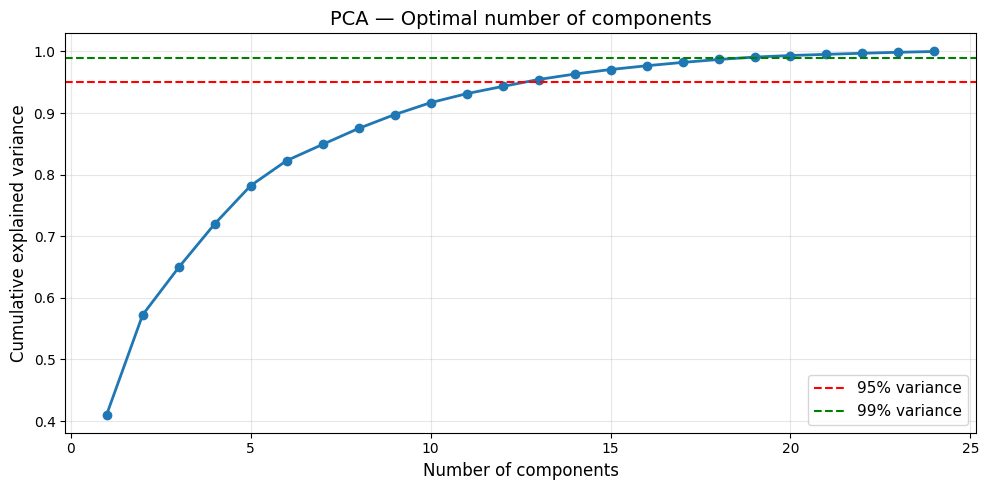

Components for 95% variance: 13
Components for 99% variance: 19


In [26]:
from sklearn.decomposition import PCA

pca_test = PCA()
pca_test.fit(X_train_sel)
cumvar = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
plt.xlabel("Number of components", fontsize=12)
plt.ylabel("Cumulative explained variance", fontsize=12)
plt.title("PCA — Optimal number of components", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")

X_train_pca: (4000, 13)
X_test_pca:  (1379, 13)


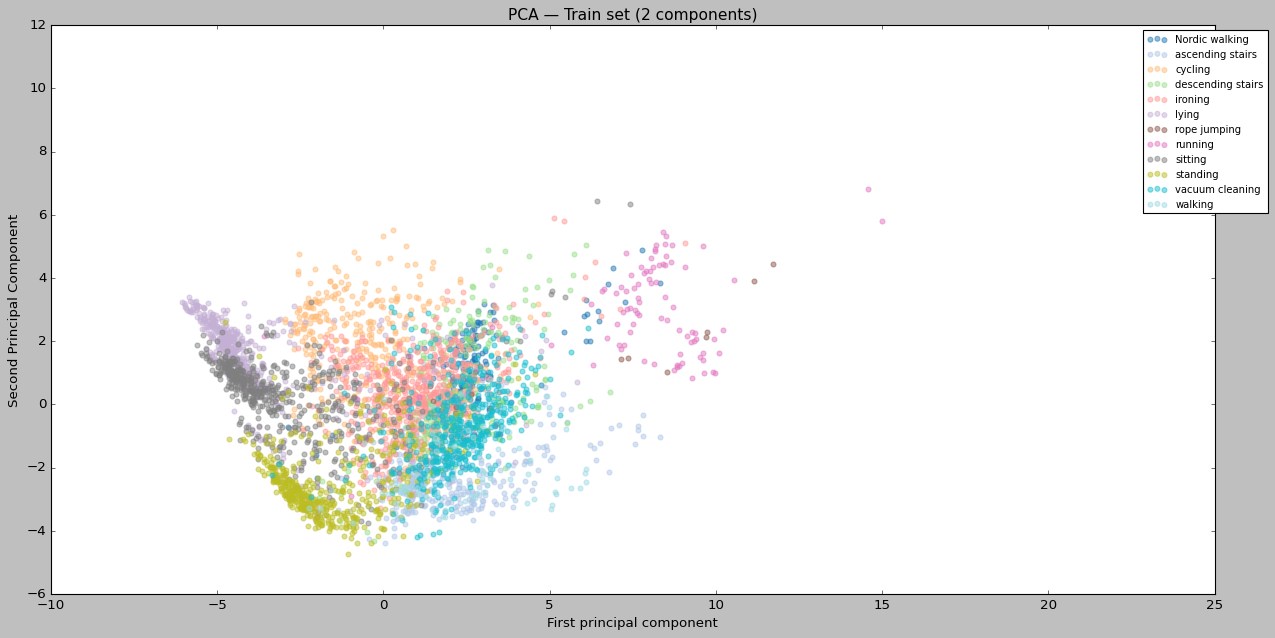

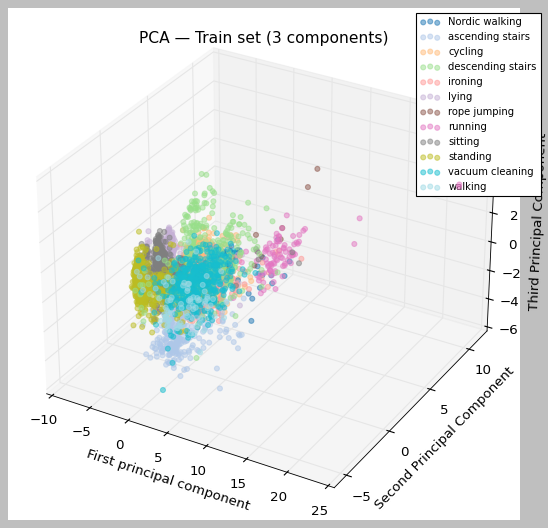

In [27]:
from utils_visual import plot_scatter_pca1 
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
le.fit([p["activity_label"] for p in training_windowpairs])
class_names = le.classes_

pca = PCA(n_components=config["PCA"]["n_comp"])


X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca  = pca.transform(X_test_sel)

print(f"X_train_pca: {X_train_pca.shape}")  # (n_windows, n_components)
print(f"X_test_pca:  {X_test_pca.shape}")

# visualize
pca_df = pd.DataFrame(X_train_pca[:, :2], columns=["PC1", "PC2"])
pca_df["label"] = y_train
plot_scatter_pca1(pca_df, c_name="label", class_names=class_names)
plt.title("PCA — Train set (2 components)", fontsize=14)

plt.show()

pca_df_3d = pd.DataFrame(X_train_pca[:, :3], columns=["PC1", "PC2", "PC3"])
pca_df_3d["label"] = y_train
plot_scatter_pca1(pca_df_3d, c_name="label", class_names=class_names)
plt.title("PCA — Train set (3 components)", fontsize=14)

plt.show()

## Training

## Model Training & Evaluation
Train SVM and Random Forest on both:
- **Selected features** (24 handpicked features)
- **PCA-reduced features** (13 components, 95% variance)

We Compare all 4 combinations to determine the best input representation before hyperparameter tuning.

In [28]:
from sklearn.svm import SVC
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# selected features
svm = SVC(C=config["classifier"]["SVC"]["C"],
          kernel=config["classifier"]["SVC"]["kernel"],
          gamma=config["classifier"]["SVC"]["gamma"],
          random_state=42)
svm.fit(X_train_sel, y_train)
y_pred_svm = svm.predict(X_test_sel)

rf = RandomForestClassifier(
    n_estimators=config["classifier_2"]["RFC"]["n_estimators"],
    max_features=config["classifier_2"]["RFC"]["max_features"],
    random_state=config["classifier_2"]["RFC"]["random_state"],
    n_jobs=config["classifier_2"]["RFC"]["n_jobs"])
rf.fit(X_train_sel, y_train)
y_pred_rf = rf.predict(X_test_sel)

# PCA features
svm_pca = SVC(C=config["classifier"]["SVC"]["C"],
              kernel=config["classifier"]["SVC"]["kernel"],
              gamma=config["classifier"]["SVC"]["gamma"],
              random_state=42)
svm_pca.fit(X_train_pca, y_train)
y_pred_svm_pca = svm_pca.predict(X_test_pca)

rf_pca = RandomForestClassifier(
    n_estimators=config["classifier_2"]["RFC"]["n_estimators"],
    max_features=config["classifier_2"]["RFC"]["max_features"],
    random_state=config["classifier_2"]["RFC"]["random_state"],
    n_jobs=config["classifier_2"]["RFC"]["n_jobs"])
rf_pca.fit(X_train_pca, y_train)
y_pred_rf_pca = rf_pca.predict(X_test_pca)

print("All models trained!")

All models trained!


SVM — Selected features
                   precision    recall  f1-score   support

   Nordic walking       0.97      0.73      0.83        88
 ascending stairs       0.74      0.87      0.80        92
          cycling       0.61      0.78      0.69       165
descending stairs       0.52      0.78      0.62        72
          ironing       0.79      0.52      0.63       228
            lying       0.65      0.94      0.77       179
     rope jumping       1.00      0.33      0.50        30
          running       0.17      0.08      0.11        25
          sitting       0.52      0.45      0.49       163
         standing       0.75      0.64      0.69       160
  vacuum cleaning       0.76      0.86      0.80       138
          walking       1.00      0.44      0.61        39

         accuracy                           0.68      1379
        macro avg       0.71      0.62      0.63      1379
     weighted avg       0.70      0.68      0.67      1379

Accuracy: 0.6824



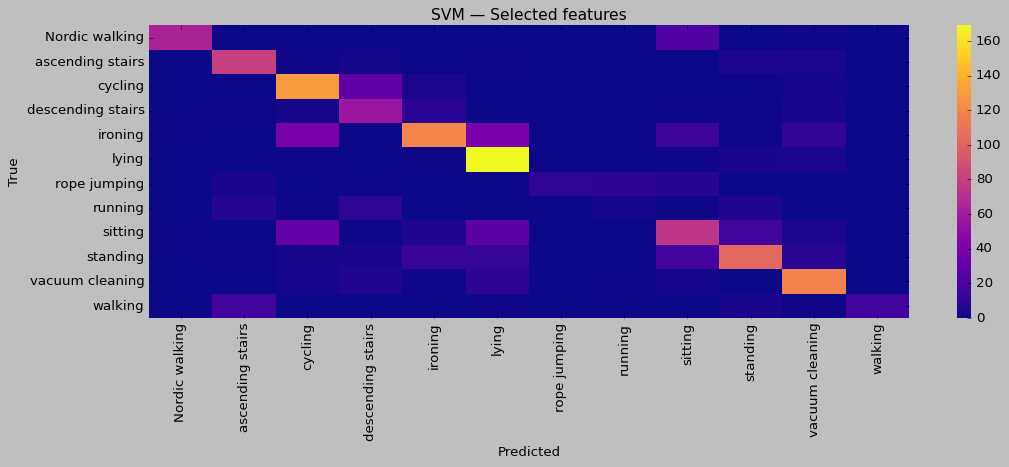

RF  — Selected features
                   precision    recall  f1-score   support

   Nordic walking       1.00      0.78      0.88        88
 ascending stairs       0.82      0.87      0.85        92
          cycling       0.74      0.82      0.78       165
descending stairs       0.62      0.83      0.71        72
          ironing       0.78      0.73      0.75       228
            lying       0.91      0.94      0.93       179
     rope jumping       0.00      0.00      0.00        30
          running       0.46      0.64      0.53        25
          sitting       0.80      0.88      0.84       163
         standing       0.83      0.59      0.69       160
  vacuum cleaning       0.71      0.90      0.79       138
          walking       0.90      0.67      0.76        39

         accuracy                           0.79      1379
        macro avg       0.71      0.72      0.71      1379
     weighted avg       0.78      0.79      0.78      1379

Accuracy: 0.7868



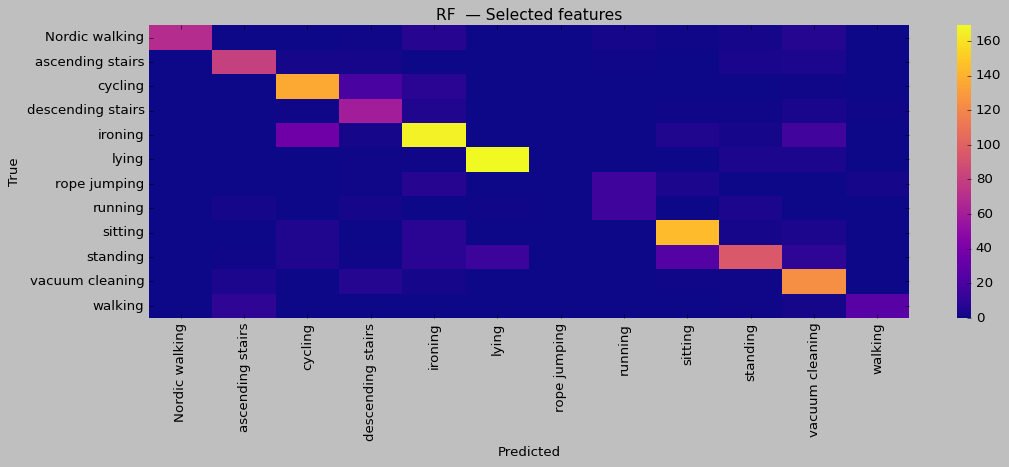

SVM — PCA
                   precision    recall  f1-score   support

   Nordic walking       0.98      0.73      0.84        88
 ascending stairs       0.82      0.88      0.85        92
          cycling       0.59      0.79      0.68       165
descending stairs       0.50      0.78      0.61        72
          ironing       0.79      0.54      0.64       228
            lying       0.76      0.94      0.84       179
     rope jumping       1.00      0.33      0.50        30
          running       0.21      0.12      0.15        25
          sitting       0.73      0.64      0.68       163
         standing       0.78      0.66      0.71       160
  vacuum cleaning       0.67      0.88      0.76       138
          walking       1.00      0.62      0.76        39

         accuracy                           0.72      1379
        macro avg       0.74      0.66      0.67      1379
     weighted avg       0.74      0.72      0.71      1379

Accuracy: 0.7179



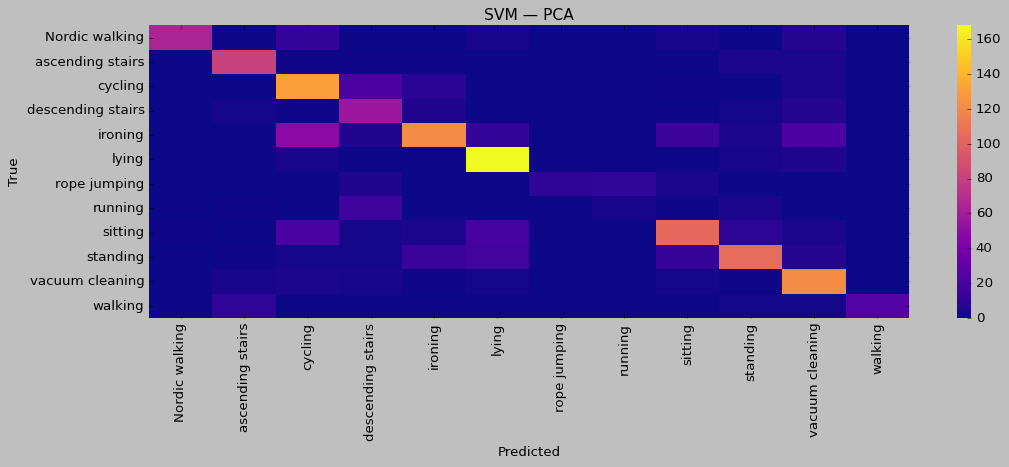

RF  — PCA
                   precision    recall  f1-score   support

   Nordic walking       1.00      0.73      0.84        88
 ascending stairs       0.87      0.84      0.85        92
          cycling       0.66      0.73      0.69       165
descending stairs       0.56      0.67      0.61        72
          ironing       0.63      0.50      0.56       228
            lying       0.80      0.94      0.86       179
     rope jumping       1.00      0.27      0.42        30
          running       0.57      0.64      0.60        25
          sitting       0.73      0.59      0.65       163
         standing       0.81      0.67      0.73       160
  vacuum cleaning       0.52      0.89      0.66       138
          walking       0.93      0.69      0.79        39

         accuracy                           0.70      1379
        macro avg       0.76      0.68      0.69      1379
     weighted avg       0.73      0.70      0.70      1379

Accuracy: 0.7034



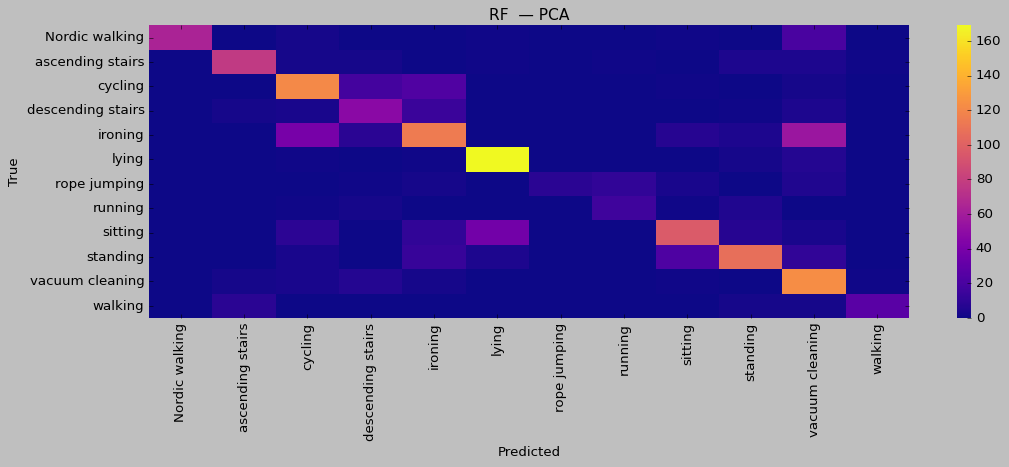

In [29]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from utils_visual import plot_heatmap

results = [
    ("SVM — Selected features", y_pred_svm),
    ("RF  — Selected features", y_pred_rf),
    ("SVM — PCA",               y_pred_svm_pca),
    ("RF  — PCA",               y_pred_rf_pca),
]

for title, y_pred in results:
    print("=" * 50)
    print(title)
    print("=" * 50)
    print(classification_report(y_test, y_pred,
                                target_names=class_names,
                                zero_division=0))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

    cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                      index=class_names, columns=class_names)
    plot_heatmap(cm)
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted"), plt.ylabel("True")
    plt.tight_layout()
   
    plt.show()

## Hyperparameter Tuning — GridSearchCV
We fine-tune SVM and Random Forest using 5-fold cross-validation on the training set only. Test subjects are never seen during tuning — only used once for final evaluation to prevent hyperparameter leakage.

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters : {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV score   : 0.7695
                   precision    recall  f1-score   support

   Nordic walking       0.88      0.73      0.80        88
 ascending stairs       0.79      0.86      0.82        92
          cycling       0.83      0.88      0.86       165
descending stairs       0.65      0.76      0.71        72
          ironing       0.77      0.51      0.61       228
            lying       0.62      0.95      0.75       179
     rope jumping       0.71      0.33      0.45        30
          running       0.77      0.40      0.53        25
          sitting       0.65      0.69      0.67       163
         standing       0.79      0.69      0.74       160
  vacuum cleaning       0.74      0.88      0.81       138
          walking       0.94      0.41      0.57        39

         accuracy                           0.73      1379
        macro avg       

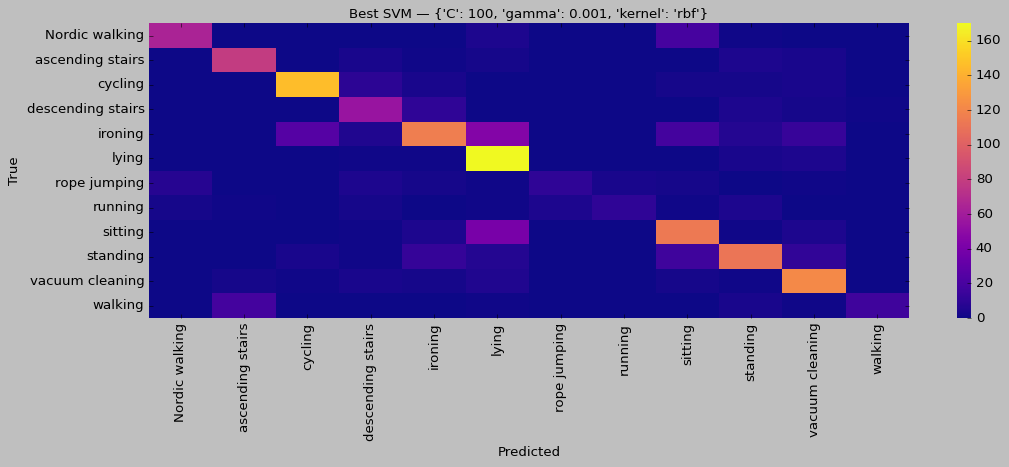

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best RF params  : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 300}
Best RF CV score: 0.7888
                   precision    recall  f1-score   support

   Nordic walking       0.99      0.83      0.90        88
 ascending stairs       0.82      0.87      0.85        92
          cycling       0.74      0.79      0.76       165
descending stairs       0.61      0.85      0.71        72
          ironing       0.76      0.74      0.75       228
            lying       0.91      0.95      0.93       179
     rope jumping       0.00      0.00      0.00        30
          running       0.50      0.64      0.56        25
          sitting       0.83      0.88      0.85       163
         standing       0.85      0.62      0.71       160
  vacuum cleaning       0.72      0.91      0.81       138
          walking       0.96      0.67      0.79        39

         accuracy                           0.79      1379
   

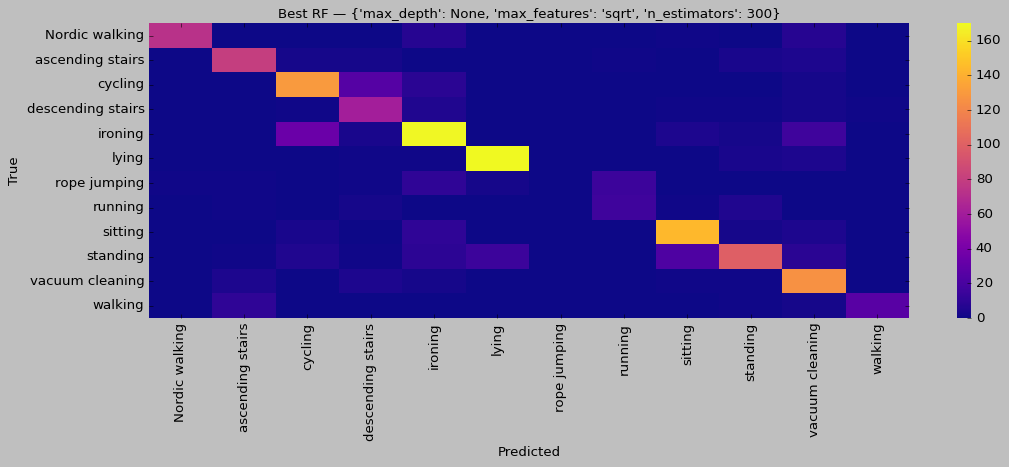

In [30]:
from sklearn.model_selection import GridSearchCV

# use feature-selected data (usually better than PCA for SVM)
grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=config["fine_tune"]["param_grid"],
    cv=config["fine_tune"]["cv"],
    verbose=config["fine_tune"]["verbose"],
    n_jobs=-1
)
grid_search.fit(X_train_sel, y_train)

print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV score   : {grid_search.best_score_:.4f}")

y_pred_best = grid_search.best_estimator_.predict(X_test_sel)
print(classification_report(y_test, y_pred_best, target_names=class_names))

cm_best = pd.DataFrame(confusion_matrix(y_test, y_pred_best),
                       index=class_names, columns=class_names)
plot_heatmap(cm_best)
plt.title(f"Best SVM — {grid_search.best_params_}", fontsize=12)
plt.xlabel("Predicted"), plt.ylabel("True")
plt.tight_layout()

plt.show()

#-------------------------------------------------#

grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=config["fine_tune_rf"]["param_grid"],
    cv=config["fine_tune_rf"]["cv"],
    verbose=config["fine_tune_rf"]["verbose"],
    n_jobs=config["fine_tune_rf"]["n_jobs"]
)
grid_search_rf.fit(X_train_sel, y_train)
y_pred_best_rf = grid_search_rf.best_estimator_.predict(X_test_sel)

print(f"Best RF params  : {grid_search_rf.best_params_}")
print(f"Best RF CV score: {grid_search_rf.best_score_:.4f}")
print(classification_report(y_test, y_pred_best_rf,
                             target_names=class_names, zero_division=0))

cm_best_rf = pd.DataFrame(confusion_matrix(y_test, y_pred_best_rf),
                          index=class_names, columns=class_names)
plot_heatmap(cm_best_rf)
plt.title(f"Best RF — {grid_search_rf.best_params_}", fontsize=12)
plt.xlabel("Predicted"), plt.ylabel("True")
plt.tight_layout()

plt.show()

                             